# Họ và Tên: Trần Tất Nguyên
# MSSV: 31251020719

# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isnull().mean())

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone" ]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns = leaky)
# print("Các cột còn lại:", list(df.columns))
print (list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` chỉ là giá trị của `survived` nhưng được encode lại dưới dạng chữ "yes"/"no" thay vì số 1/0

-> Hai cột này mang chính xác cùng một thông tin. Nếu để alive trong tập đặc trưng, mô hình khi train sẽ biết trước đáp án cần dự đoán khiến cho kết quả đánh giá không phản đúng khả năng dự đoán của mô hình trên dữ liệu thực tế

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print(f"Số dòng, số cột: {df.shape}")
print(f"Biến mục tiêu là survived (1 = sống sót, 0 = không sống sót)\n")
print(df.info())

print(" Biến phân loại ".center(30,"-"))
print(df.describe(include = "O"))

print("\n"," Biến số ".center(30,"-"))
print(df.describe())

Số dòng, số cột: (891, 8)
Biến mục tiêu là survived (1 = sống sót, 0 = không sống sót)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None
------- Biến phân loại -------
         sex embarked
count    891      889
unique     2        3
top     male        S
freq     577      644

 ---------- Biến số -----------
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838   

**Trả lời 2 (biến số vs biến phân loại):**

- **Biến số (numeric):** `age`, `sibsp`, `parch`, `fare`, `pclass` 
- **Biến phân loại (categorical):** `sex`, `embarked` 

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_per = df.isnull().mean() *100

print(" Thống kê missing value ".center(30,"-"))
missing_table = pd.DataFrame(data = {
    "Số lượng thiếu" : missing_count,
    "% thiếu" : missing_per
})

display(missing_table)

--- Thống kê missing value ---


,Số lượng thiếu,% thiếu
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | 19.87% (177 dòng) | Điền median | Cách đơn giản nhất, tỷ lệ thiếu không quá lớn. Median không nhạy cảm với outlier như mean |
| `embarked` | 0.22% (2 dòng) | Điền mode | Số lượng thiếu rất nhỏ, tính chất là biến phân loại. Việc điền mode gần như không ảnh hưởng tới phân phối chung|

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):     # trả về số lượng outlier theo IQR
    s = s.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (((s < lower) | (s > upper)).sum())

def dem_outlier_zscore(s, nguong=3.0):    # trả về số lượng outlier theo Z-score
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return (z > nguong).sum()

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    so_iqr = dem_outlier_iqr(df[col])
    so_z = dem_outlier_zscore(df[col])
    print(f"{col}: IQR = {so_iqr} outlier | Z-score = {so_z} outlier")
    
# Bổ sung phần chứng minh cột fare tồn tại số lượng outlier tương đối là do sự xuất hiện của vé hạng nhất
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
fare_outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]
fare_outliers["pclass"].value_counts(normalize=True).sort_index() * 100

age: IQR = 11 outlier | Z-score = 2 outlier
fare: IQR = 116 outlier | Z-score = 20 outlier


pclass
1    89.655172
2     4.310345
3     6.034483
Name: proportion, dtype: float64

**Trả lời 4 (quyết định với outlier của `fare`):**

Qua hàm đếm, ta có thể thấy `fare` có 116 outlier theo IQR, 20 theo Z-score. Sự chênh lệch lớn giữa 2 phương pháp cho thấy phân phối của `fare` không theo phân phối chuẩn, Z-score do chứa mean và std nên bị ảnh hưởng nhiều bởi outlier, phát hiện được ít hơn

Như vậy, nên giữ lại các outlier của `fare` thay vì loại bỏ. Vé đắt bất thường không phải là lỗi nhập liệu mà là do sự xuất hiện của loại vé hạng 1 (89,66% outliers thuộc pclass = 1) làm dữ liệu lệch phải. Vì vậy cần phải giữ lại `fare` để không làm mất thông tin quan trọng cũng như ảnh hưởng tới khả năng dự đoán của mô hình

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

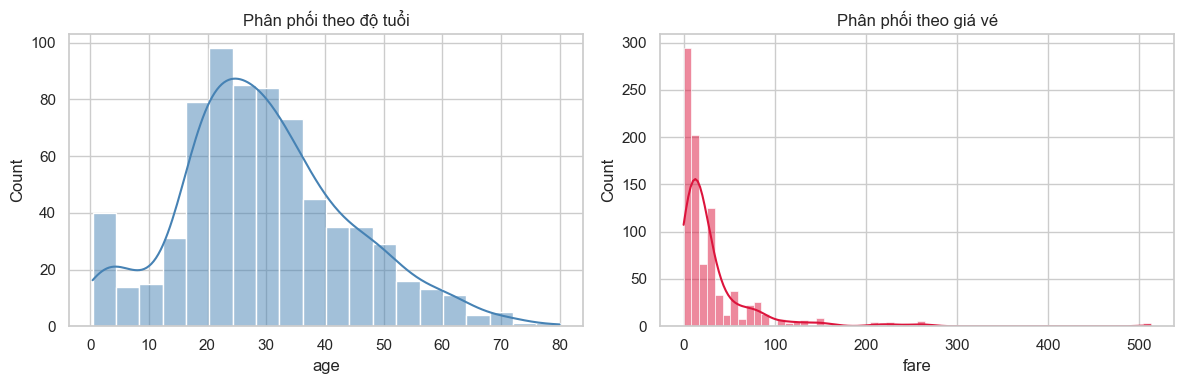

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"].dropna(), kde = True, ax = axes[0], color = "steelblue")
axes[0].set_title("Phân phối theo độ tuổi")

sns.histplot(df["fare"].dropna(), kde = True, ax = axes[1], color = "crimson")
axes[1].set_title("Phân phối theo giá vé")
plt.tight_layout()
plt.show()

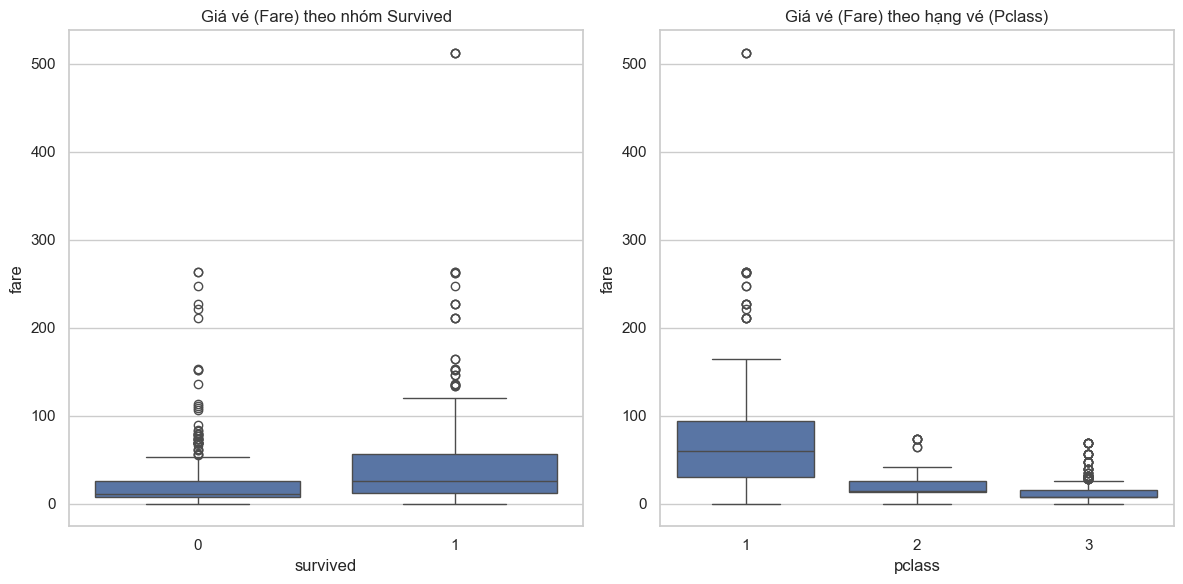

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=df, x="survived", y="fare", ax=axes[0])
axes[0].set_title("Giá vé (Fare) theo nhóm Survived")
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("Giá vé (Fare) theo hạng vé (Pclass)")
plt.tight_layout()
plt.show()

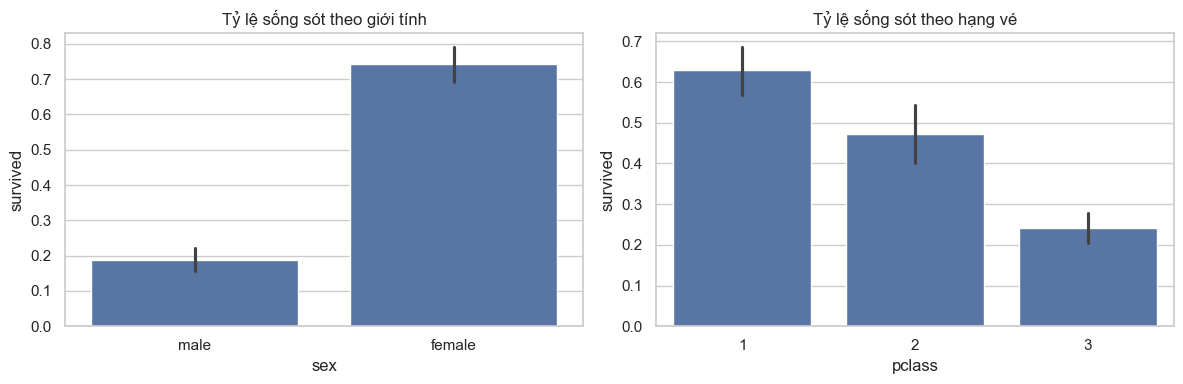

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo giới tính")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo hạng vé")
plt.tight_layout()
plt.show()


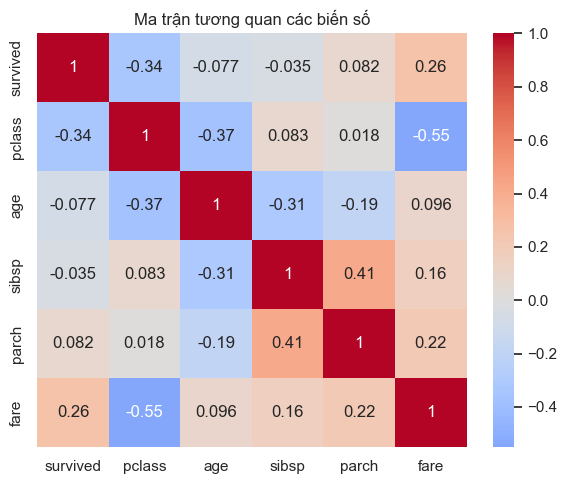

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** `age` hơi lệch phải, tập trung nhiều ở khoảng 20–40 tuổi. `fare` lệch phải mạnh, đa số hành khách trên tàu chi trả mức giá vé thấp nhưng có một số ít trả giá rất cao (vé hạng nhất) kéo dài đuôi phân phối

- **Boxplot:** 
  - Theo `survived`, nhóm `survived = 1` có trung vị `fare` cao hơn nhóm `survived = 0`
  - Theo `pclass`, trung vị `fare` giảm dần từ hạng 1 xuống hạng 3

    -> Cả hai đều có nhiều outlier ở biên trên

- **Bar survival:** 
  - **Theo giới tính (sex):** Nữ giới có tỷ lệ sống sót trên 70%, nam giới khoảng 20% (chênh lệch hơn 50 điểm phần trăm)
  - **Theo hạng vé (pclass):** hạng 1 sống sót trên 60%, hạng 2 gần 50%, hạng 3 khoảng 25%. Điều này cho thấy cả giới tính lẫn hạng vé đều ảnh hưởng mạnh nhưng giới tính là yếu tố nổi bật hơn

- **Heatmap:** 
  - `survived` tương quan âm với `pclass` (-0.34) và dương với `fare` (0.26) 
  -> hạng vé càng thấp (sang trọng), giá vé càng cao thì khả năng sống sót càng cao
  - `age` và `sibsp` tương quan yếu với `survived` (-0.08 và -0.04) cho thấy 2 yếu tố này gần như không ảnh hưởng không tới khả năng sống sót

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = "survived")
y = df.survived

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size = 0.15, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp)


# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập

print(f"Train/Val/Test shape: {X_train.shape}, {X_val.shape}, {X_test.shape}")
print("\nTỷ lệ sống sót:")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())

Train/Val/Test shape: (623, 7), (134, 7), (134, 7)

Tỷ lệ sống sót:
Train: 0.38362760834670945
Val:   0.3880597014925373
Test:  0.3805970149253731


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))


(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Chỉ fit trên tập train để các tham số của bước tiền xử lý (median của SimpleImputer, các biến trong RobustScaler hay các category trong OneHotEncoder) được học hoàn toàn từ tập train. Và sau đó các tham số này mới được áp dụng cho tập validation và test

-> Nếu fit trên toàn bộ dữ liệu, thông tin từ validation hoặc test sẽ bị sử dụng trong quá trình tiền xử lý dẫn đến data leakage và làm kết quả đánh giá mô hình không còn khách quan

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True) * 100)


survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến `survived` mất cân bằng nhẹ: vì tỷ lệ thực tế trên dataset là 61.6% không sống sót và 38.4% sống sót
2. Nếu chỉ nhìn Accuracy, ta có thể bị đánh lừa khi mô hình luôn dự đoán lớp đa số (survived  = 0) và vẫn đạt accuracy 61.6% nhưng không nhận diện được những người sống sót
3. Với dataset Titanic, F1-score là metric phù hợp vì nó cân bằng giữa Precision và Recall. Cả hai mục tiêu giảm thiểu trường hợp phát hiện thiếu người sóng sót (recall thấp) hay dự đoán nhầm (precision thấp) đều đáng quan tâm. F1 cân bằng được cả hai, phù hợp hơn Accuracy đơn thuần khi có mất cân bằng lớp


---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót là **giới tính (sex)**. Nữ giới sống sót khoảng 75%, gấp hơn 3 lần so với nam giới (chênh hơn 50 điểm phần trăm). Tiếp theo là kế **hạng vé (`pclass`, corr = -0.34)** và **giá vé (`fare`, corr = 0.26)**

2. Cột thiếu nhiều nhất trong tập dữ liệu còn giữ lại là **`age`** (19.87%, 177/891 dòng) được xử lý bằng cách điền **median**; cột **`deck`** (77% thiếu) xử lý bằng cách loại bỏ cả cột

3. Biến mục tiêu `survived` **mất cân bằng nhẹ** (61.6% / 38.4%), nên nếu chỉ dùng Accuracy để đánh giá mô hình sẽ có khả năng phán đoán sai bởi mô hình luôn đoán lớp đa số -> cần ưu tiên F1-score khi đánh giá trong trường hợp này

4. Các đặc trưng số như `age`, `fare`, `sibsp`, `parch` cần **scaling** (đặc biệt `fare` cần scaler không bị ảnh hưởng bởi outlier như RobustScaler vì tìm thấy tới 116 outlier theo IQR trong khi chỉ có 20 theo z-score) vì chúng có thang đo khác nhau. Các đặc trưng phân loại (categorical) như `sex`, `embarked` cần **encoding** (one-hot) vì mô hình học máy không xử lý trực tiếp dạng chữ

5. Một điểm thú vị là `fare` có nhiều outlier (116 theo IQR) nhưng không nên loại bỏ. Xét khoảng 89.6% các outlier thuộc pclass = 1, ta có thể thấy `fare` xuất hiện tình trạng nhiều outlier không phải lỗi nhập liệu mà là do các giá vé cao của hành khách hạng nhất

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
